In [14]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

import re
import glob

##### auxiliares

In [15]:
def procesafile(at, lvl, folder):
    barrido = []
    Probs = [[] for _ in np.arange(lvl**at)]
    label = f"{at}at{lvl}lvl"
    title = ""
    niveles = None
    tiempo = None
    has_omega = (at > 1) # 1 átomo no tiene Omega_EE

    files = glob.glob(os.path.join(folder, label + '*.h5'))
    for file in files:
        with h5py.File(file, 'r') as f:
            dataset = os.path.basename(file).replace('.h5', '')

            d = f[dataset]
            attrs = {k: d.attrs.get(k) for k in d.attrs}
            title = '\n'.join(f'{k} = {v}' for k, v in attrs.items() if k not in ('t', 'probs_label', 'Omega_EE'))
            
            niveles = f[dataset].attrs['probs_label']
            tt = f[dataset].attrs['t']
            tiempo = np.linspace(float(tt[0]), float(tt[1]), int(tt[2]))

            Omega_EE = f[dataset].attrs['Omega_EE'] if has_omega else 0.0
            barrido.append(Omega_EE)

            rho = f[dataset][:]
            lvl_prob = [rho[:, i] for i in np.arange(lvl**at)]
            for i, ele in enumerate(lvl_prob):
                Probs[i].append(ele)

    # ordena por Omega_EE
    barrido = np.array(barrido)
    sorti   = np.argsort(barrido)
    barrido = barrido[sorti]
    Probs   = [np.array(p)[sorti] for p in Probs]

    return {"barrido": barrido, "Probs": Probs, "niveles": niveles, "tiempo": tiempo, "title": title, "at": at, "has_omega": has_omega}

In [16]:
from scipy.signal import find_peaks
def f_dominante(signal, tiempo):
    freq = None
    peaks, _ = find_peaks(signal, height=np.max(signal)*0.5)  # altura mínima 50% del máximo
    if len(peaks) > 1:
        T = tiempo[peaks[1]] - tiempo[peaks[0]]
        freq = 1 / T
    return freq
    
def p_probs(plvl, datasets, omega_filter=None):
    pattern = re.compile(plvl.replace("_", "."))
    fig, ax = plt.subplots()
    title_set = set()
    freqs = {}

    for ds in datasets:
        barrido = ds["barrido"]
        Probs = ds["Probs"]
        niveles = ds["niveles"]
        tiempo = ds["tiempo"]
        at = ds["at"]

        pattern_str = plvl.replace("_", ".")
        pattern_str = pattern_str[:at] # recorta al largo del dataset
        pattern = re.compile(f"^{pattern_str}$")
        indices = [i for i, lbl in enumerate(niveles) if pattern.search(lbl)]
        prob = np.sum([Probs[i] for i in indices], axis=0)  # shape: (n_omega, n_tiempo)
        if ds["has_omega"]:
            for j, dist in enumerate(barrido):
                # si hay filtro de omega, saltar los que no coincidan
                if omega_filter is not None and not np.isclose(dist, omega_filter):
                    continue
                label = f"{at}at; Ω_EE={dist}"
                ax.plot(tiempo, prob[j], '-', label=label, markersize=5)
                freqs[label] = f_dominante(prob[j], tiempo)
        else:
            label = f"{at}at"
            ax.plot(tiempo, prob[0], '-', label=label, markersize=5)
            freqs[label] = f_dominante(prob[0], tiempo)
        title_set.add(ds["title"])

    ax.set_title("".join(title_set) + f"\n P([{plvl}])")
    ax.set_xlabel("tiempo [s]")
    ax.set_ylabel("probabilidad de ocupación")
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.legend()
    return fig, freqs

##### graficas

In [22]:
lvl = 4
folder = f"{lvl}lvl_distancias"

/tmp/ipykernel_570865/3282300592.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


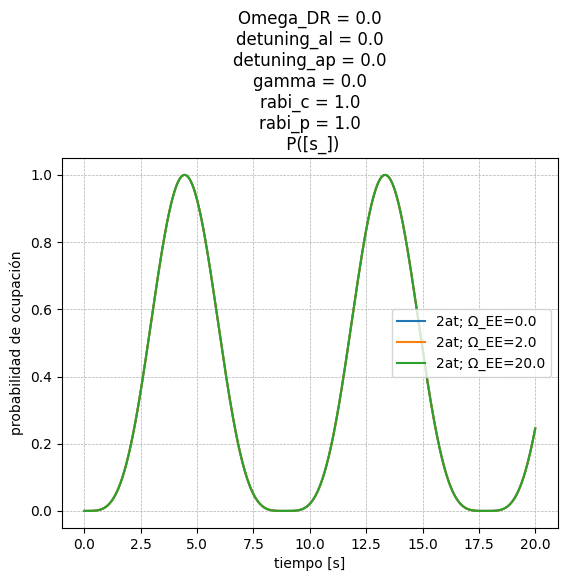

In [23]:
ds_2at = procesafile(2, lvl, folder)
fig, freqs = p_probs("s_", datasets=[ds_2at])
fig.show()

/tmp/ipykernel_570865/3230862537.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


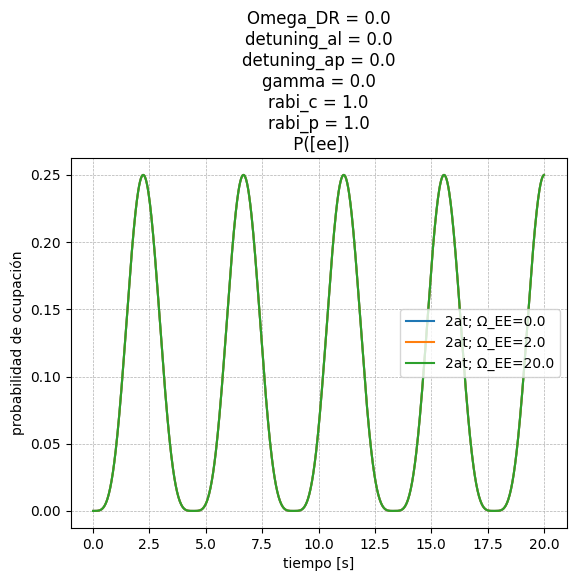

In [24]:
fig, freqs = p_probs("ee", datasets=[ds_2at])
fig.show()

/tmp/ipykernel_570865/524073697.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


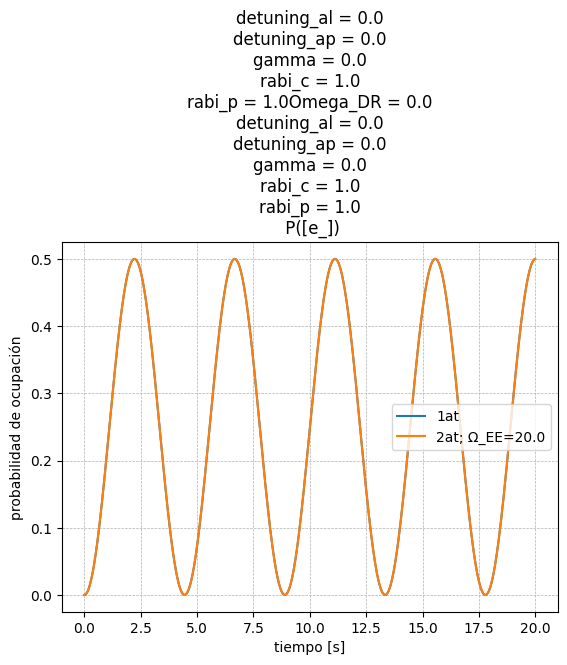

In [25]:
ds_1at = procesafile(1, lvl, folder)
ds_2at = procesafile(2, lvl, folder)
fig, freqs = p_probs("e_", datasets=[ds_1at, ds_2at], omega_filter=20.0)
fig.show()

In [26]:
freqs["2at; Ω_EE=20.0"] / freqs["1at"]

np.float64(1.0)